# 07-2. 검색 결과를 뉴스 리포트로 정리하기

이 실습은 1단계 검색 그래프에 LLM 리포트 작성 노드를 추가하는 예제이다.

## 학습 목표

1. 검색 노드와 리포트 작성 노드를 순차적으로 연결한다.
2. Tavily 검색 결과를 LLM 프롬프트에 넣기 좋은 문자열로 변환한다.
3. LLM이 검색 결과를 바탕으로 뉴스 리포트를 생성하도록 구성한다.
4. `START → 검색 → 리포트작성 → END` 흐름을 이해한다.

## 전체 흐름

```text
START
  ↓
검색
  ↓
리포트작성
  ↓
END
```


## 0. 설치 패키지

이 실습은 LangGraph, OpenAI 모델, Tavily 검색 도구를 사용한다.  
처음 실행하는 환경에서는 아래 명령으로 필요한 패키지를 설치한다.

```bash
uv add langgraph langchain-openai langchain-tavily langchain-core python-dotenv grandalf
```

`.env` 파일에는 다음 값을 설정한다.

```text
OPENAI_API_KEY=발급받은_OpenAI_API_Key
TAVILY_API_KEY=발급받은_Tavily_API_Key
```


In [1]:
# 공통 환경 설정
# - .env 파일에서 API Key를 읽는다.
# - API Key가 없으면 실습 초반에 명확한 오류를 발생시킨다.
import os
from dotenv import load_dotenv

load_dotenv(override=True, dotenv_path="../.env")

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")

if not OPENAI_API_KEY:
    raise ValueError("OPENAI_API_KEY가 설정되어 있지 않다. ../.env 파일을 확인한다.")

if not TAVILY_API_KEY:
    raise ValueError("TAVILY_API_KEY가 설정되어 있지 않다. ../.env 파일을 확인한다.")

print("환경 변수 로드 완료")

환경 변수 로드 완료


In [2]:
# LangGraph, LLM, Tavily 검색 도구를 불러온다.
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_tavily import TavilySearch
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from IPython.display import Image, display

# LLM은 검색 결과를 자연어 리포트로 정리할 때 사용한다.
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.2)

# TavilySearch는 외부 웹 검색을 수행하는 도구이다.
tavily_tool = TavilySearch(max_results=5)

In [ ]:
def normalize_tavily_results(raw_result) -> list[dict]:
    """Tavily 검색 결과를 list[dict] 형태로 정리한다.

    TavilySearch의 반환값은 보통 {"results": [...]} 형태이다.
    실습에서는 이후 노드가 사용하기 쉽도록 검색 결과 리스트만 추출한다.
    """
    if isinstance(raw_result, dict):
        return raw_result.get("results", [])

    if isinstance(raw_result, list):
        return raw_result

    return []


def format_search_results(results: list[dict]) -> str:
    """검색 결과를 LLM 프롬프트에 넣기 쉬운 문자열로 변환한다."""
    if not results:
        return "검색 결과가 없다."

    lines = []
    for idx, item in enumerate(results, start=1):
        title = item.get("title", "제목 없음")
        url = item.get("url", "URL 없음")
        content = item.get("content", "내용 없음")

        lines.append(
            f"[{idx}] {title}\n"
            f"URL: {url}\n"
            f"내용: {content}"
        )

    return "\n\n".join(lines)


def show_graph(app):
    """그래프 구조를 시각화한다.

    Mermaid 이미지 생성이 실패하면 ASCII 그래프로 대체한다.
    """
    try:
        display(Image(app.get_graph().draw_mermaid_png()))
    except Exception as e:
        print(f"Mermaid 이미지 생성 실패: {e}")
        print(app.get_graph().draw_ascii())

## 1. State 정의

2단계에서는 검색 결과를 바탕으로 최종 리포트를 생성한다.  
따라서 `report` 필드를 추가한다.

| 필드 | 의미 |
|---|---|
| `topic` | 사용자가 알고 싶은 주제 |
| `search_query` | 실제 검색어 |
| `search_results` | Tavily 검색 결과 |
| `report` | LLM이 작성한 최종 리포트 |


In [4]:
class ReportState(TypedDict):
    # 사용자가 입력한 원래 주제이다.
    topic: str

    # Tavily 검색에 사용한 검색어이다.
    search_query: str

    # Tavily에서 받은 검색 결과 목록이다.
    search_results: list[dict]

    # LLM이 작성한 뉴스 리포트이다.
    report: str

## 2. 검색 노드 정의

1단계와 동일하게 Tavily 검색을 수행한다.  
검색 노드는 `search_query`와 `search_results`를 반환한다.


In [5]:
def search_node(state: ReportState) -> dict:
    """Tavily 검색을 수행하는 노드이다."""

    query = state["topic"]
    print(f"검색어: {query}")

    raw_result = tavily_tool.invoke({"query": query})
    results = normalize_tavily_results(raw_result)

    print(f"검색 결과 수: {len(results)}")

    return {
        "search_query": query,
        "search_results": results,
    }

## 3. 리포트 작성 체인 정의

LLM은 검색 결과 리스트를 직접 이해하기 어렵다.  
따라서 `format_search_results()` 함수로 검색 결과를 문자열로 바꾼 뒤 프롬프트에 넣는다.

날짜, 수치, 기관명은 검색 결과에 있는 경우에만 사용한다.  
제공되지 않은 정보는 추정하지 않는다.


In [ ]:
report_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """
너는 검색 결과를 바탕으로 짧은 뉴스 브리핑을 작성하는 AI이다.

작성 규칙:
1. 검색 결과에 있는 내용만 사용한다.
2. 날짜, 수치, 기관명은 원문에 있을 때만 사용한다.
3. 제공되지 않은 정보는 추정하지 않는다.
4. 한국어로 작성한다.
5. 제목, 핵심 요약, 주요 내용, 참고 링크 순서로 정리한다.
""".strip(),
    ),
    (
        "human",
        """
주제: {topic}

검색 결과:
{search_results}

위 검색 결과를 바탕으로 초보자도 이해할 수 있는 뉴스 리포트를 작성하라.
""".strip(),
    ),
])

# 프롬프트 → LLM → 문자열 출력 파서 순서로 실행되는 LangChain 체인이다.
report_chain = report_prompt | llm | StrOutputParser()

## 4. 리포트 작성 노드 정의

이 노드는 검색 결과를 받아 LLM 리포트를 생성한다.

입력으로 사용하는 State 값은 다음과 같다.

- `topic`
- `search_results`

반환하는 State 값은 다음과 같다.

- `report`


In [ ]:
def report_node(state: ReportState) -> dict:
    """검색 결과를 바탕으로 뉴스 리포트를 작성하는 노드이다."""

    # 검색 결과를 프롬프트에 넣기 좋은 문자열로 변환한다.
    search_text = format_search_results(state["search_results"])

    # LLM 체인을 실행해 리포트를 생성한다.
    report = report_chain.invoke({
        "topic": state["topic"],
        "search_results": search_text,
    })

    return {"report": report}

## 5. 그래프 구성

검색 노드 다음에 리포트 작성 노드를 연결한다.

```text
START → 검색 → 리포트작성 → END
```


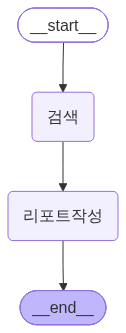

In [ ]:
builder = StateGraph(ReportState)

# 두 개의 노드를 등록한다.
builder.add_node("검색", search_node)
builder.add_node("리포트작성", report_node)

# 순차 실행 흐름을 정의한다.
builder.add_edge(START, "검색")
builder.add_edge("검색", "리포트작성")
builder.add_edge("리포트작성", END)

app = builder.compile()

show_graph(app)

## 6. 그래프 실행

최종 결과에서 `report` 값을 확인한다.


In [9]:
result = app.invoke({
    "topic": "인공지능 최신 동향",
    "search_query": "",
    "search_results": [],
    "report": "",
})

print(result["report"])

검색어: 인공지능 최신 동향
검색 결과 수: 5
### 제목
2025년 인공지능 최신 동향: 거대 언어 모델과 AI 코딩 에이전트의 발전

### 핵심 요약
2025년 인공지능 분야에서는 거대 언어 모델과 AI 코딩 에이전트의 발전이 두드러지며, 다양한 정책과 기술 혁신이 이루어지고 있다. 특히, AI의 성능이 인간 수준에 가까워지고 있으며, 새로운 AI 모델들이 지속적으로 등장하고 있다.

### 주요 내용
최근 발표된 인공지능 기술 동향에 따르면, 2025년에는 클로드 4와 그록 4와 같은 거대 언어 모델이 주목받고 있다. 클로드 4는 코딩 및 에이전트 분야에서 새로운 시대를 열었다고 평가받으며, 소프트웨어 개발 작업에서 높은 성능을 보이고 있다. 또한, AI 브라우저와 월드 파운데이션 모델(WFM)도 중요한 기술로 부각되고 있다.

정책적으로는 중국이 'AI 플러스' 심화 추진을 위한 로드맵을 발표하고, 대만은 AI 기본법을 통과시켰다. 미국 캘리포니아주는 미성년자 보호를 위한 AI 챗봇 규제를 통과시키며, AI 안전 거버넌스 프레임워크 2.0을 발표한 중국의 움직임도 주목할 만하다.

AI 산업의 시장 규모는 2023년 기준 2,146억 달러에 달하며, 2030년에는 1조 3,391억 달러로 성장할 것으로 전망된다. 이러한 성장세는 AI 기술이 실생활에 점점 더 많이 적용되고 있다는 것을 보여준다.

### 참고 링크
- [인공지능 최신기술동향 -2025년7월](https://www.youtube.com/watch?v=liww5LmgOpw)
- [인공지능 산업의 최신동향: 2025년 10월 - FAIR AI](https://m.fairai.or.kr/research/reports/414)
- [인공지능 분야 산업·기술 동향 및 이슈](https://ettrends.etri.re.kr/ettrends/212/0905212008/0905212008.html)


## 7. stream으로 단계별 실행 확인

`stream()`을 사용하면 검색 노드와 리포트 작성 노드가 각각 어떤 값을 반환하는지 확인할 수 있다.


In [11]:
for event in app.stream(
    {
        "topic": "생성형 AI 교육 트렌드, url 오픈 가능한 자료만 추출하기",
        "search_query": "",
        "search_results": [],
        "report": "",
    },
    stream_mode="updates",
):
    print(event)
    for update_data in event.values():
        print(update_data)
    # for update_data in event.values():
    #     if "search_results" in update_data:
    #         for i, item in enumerate(update_data["search_results"], start=1):
    #             print(f"\n[{i}] {item.get('title')}")
    #             print(item.get("url"))
    #             print(item.get("content"))

검색어: 생성형 AI 교육 트렌드, url 오픈 가능한 자료만 추출하기
검색 결과 수: 5
{'검색': {'search_query': '생성형 AI 교육 트렌드, url 오픈 가능한 자료만 추출하기', 'search_results': [{'url': 'https://www.youtube.com/watch?v=jPBevYJ-6pI', 'title': '[Generative AI Training] Master AI for Work: The Essentials', 'content': '📚 본 강의 소개\n이 강의 영상은 GSC의 "3시간으로 평생 써먹는 생성형 AI+바이브 코딩 업무 자동화" 교육과정입니다.\n비개발자도 쉽게 따라할 수 있는 실무 중심 AI 활용법을 배울 수 있습니다.\n\n📢 아래 링크에서 교안과 학습자료를 다운받아 학습해보세요. \n👉 \n\n💬 궁금한 점이 있으시면 댓글로 남겨주세요!\n구독과 좋아요는 더 좋은 콘텐츠 제작에 큰 힘이 됩니다. 🙏\n\n#생성형AI #생성형AI교육 #ChatGPT #AI교육 #멀티모달AI #AI원리 #딥러닝 #GPT #인공지능 #AI트렌드 #Gemini #Claude #DeepSeek #AI업무활용 #프롬프트엔지니어링 #바이브코딩 #GSC #글로벌소프트웨어캠퍼스 [...] ✅ 이 영상을 보면 알 수 있는 것들\n- ChatGPT는 어떻게 당신의 질문을 이해할까? (텍스트 임베딩의 비밀)\n- 1,750억 개 매개변수의 정체와 AI 성능의 핵심 요소\n- GPT-1부터 ChatGPT까지, 4년간의 폭발적 진화 과정\n- LLM vs SLM, 당신에게 맞는 AI 모델은?\n- 2025년 AI 트렌드: ChatGPT, Gemini, Claude 누가 1등?\n- 텍스트+이미지+영상을 동시에 처리하는 멀티모달 AI의 작동 원리\n\n💡 AI 도구를 그냥 쓰는 사람과 원리를 아는 사람의 차이\n단순히 프롬프트만 입력하는 것을 넘어, AI의 작동 원리를 이해하면\n더 정확하고 효율적으로 AI를 활용할 수 있습니다.\n\n📌

## 정리

이 단계에서 확인한 내용은 다음과 같다.

1. 하나의 그래프 안에서 외부 검색과 LLM 생성을 순차적으로 연결할 수 있다.
2. 검색 결과는 LLM이 이해할 수 있도록 문자열로 정리해야 한다.
3. LangGraph의 각 노드는 자신이 담당하는 작업만 수행하고, 변경할 State 값만 반환한다.
4. 다음 단계에서는 검색 결과가 부족할 때 다시 검색하는 조건부 흐름을 추가한다.


---

## 핵심 정리

```python
# 1. Tavily Search 도구 초기화
from langchain_tavily import TavilySearch

tavily_tool = TavilySearch(max_results=5)

raw_result = tavily_tool.invoke({"query": "검색어"})
results = raw_result["results"]


# 2. 검색 결과를 LLM 입력용 문자열로 변환
def format_search_results(results: list[dict]) -> str:
    if not results:
        return "검색 결과가 없다."

    lines = []

    for idx, item in enumerate(results, start=1):
        title = item.get("title", "제목 없음")
        url = item.get("url", "URL 없음")
        content = item.get("content", "내용 없음")

        lines.append(
            f"[{idx}] {title}\n"
            f"URL: {url}\n"
            f"내용: {content}"
        )

    return "\n\n".join(lines)


# 3. State 정의
from typing_extensions import TypedDict

class ReportState(TypedDict):
    topic: str
    search_query: str
    search_results: list[dict]
    report: str


# 4. 검색 노드
def search_node(state: ReportState) -> dict:
    query = state["topic"]

    raw_result = tavily_tool.invoke({"query": query})
    results = raw_result["results"]

    return {
        "search_query": query,
        "search_results": results,
    }


# 5. 리포트 작성 노드
def report_node(state: ReportState) -> dict:
    search_text = format_search_results(state["search_results"])

    report = report_chain.invoke({
        "topic": state["topic"],
        "search_results": search_text,
    })

    return {"report": report}


# 6. 그래프 구성
from langgraph.graph import StateGraph, START, END

builder = StateGraph(ReportState)

builder.add_node("검색", search_node)
builder.add_node("리포트작성", report_node)

builder.add_edge(START, "검색")
builder.add_edge("검색", "리포트작성")
builder.add_edge("리포트작성", END)

app = builder.compile()
```

- 노드 설명 
   
| 노드 | 역할 |
|---|---|
| 검색 | 사용자의 주제를 검색어로 사용해 Tavily Search API로 웹 검색을 수행한다. |
| 리포트작성 | 검색 결과를 LLM 프롬프트에 넣기 좋은 문자열로 변환한 뒤 뉴스 리포트를 생성한다. |

- State 필드 설명    

| State 필드 | 의미 |
|---|---|
| `topic` | 사용자가 알고 싶은 원래 주제이다. |
| `search_query` | 실제 Tavily 검색에 사용한 검색어이다. |
| `search_results` | Tavily에서 반환한 검색 결과 목록이다. |
| `report` | LLM이 검색 결과를 바탕으로 작성한 최종 리포트이다. |

이 실습은 LangGraph에서 **외부 검색 API 호출 결과를 LLM 생성 노드로 전달하는 기본 파이프라인** 예제이다.

핵심 흐름은 다음과 같다.

```text
START
  ↓
검색
  ↓
리포트작성
  ↓
END
```

즉, 07-1이 “검색 도구를 노드로 연결하는 실습”이라면, 07-2는 여기에 **LLM 후처리 노드**를 추가해 검색 결과를 사람이 읽기 쉬운 리포트로 변환하는 실습이다.